### Classification Example



In [27]:
# Packages use in data visualization and wranglin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [28]:
# Load the data

data = load_breast_cancer()

# Convert this dataframe
df           = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

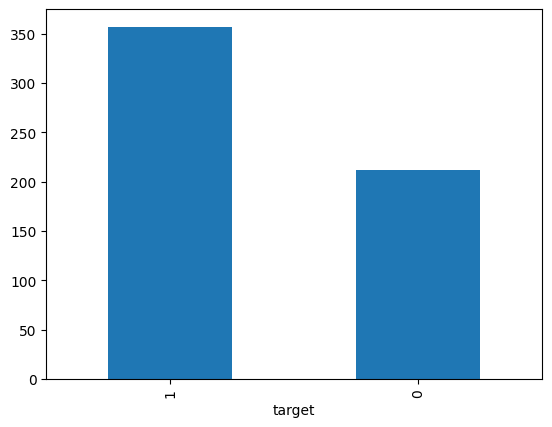

In [29]:
# We can visualize the class distribution
df.target.value_counts().plot(kind='bar')
plt.show()

NB. All foundation concepts of the AML will be applicable in Neural Network

- Evaluation models
- Feature Engineering
- Overfitting Vs Underfitting
- Feature splitting
- Data Preprocessing ~ Data cleaning

In [30]:
# Split our data into Target and Input Features

X = df.drop('target', axis=1)   # df.drop(columns=['target'])
y = df.target

In [31]:
# Split our data Test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [32]:
# Data Preparation

scaler   = StandardScaler()   # Create an instance object
X_train  = scaler.fit_transform(X_train)
X_test   = scaler.transform(X_test)

**Building Neural Networks**

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

**Build an Neural Network design**

1. Input layer ,
2. Hidden Layer(s),
3. Output Layer(1)

In [39]:
# Means we are building a linear stack of layers one after another  # Output for each layer becames in input for the next layer

model = Sequential()
model.add(Dense(30, activation='relu',input_shape=(X_train.shape[1],))) # activation is to help network learn non-linear patterns  # First Input + Hidden Layer
model.add(Dense(15, activation='relu'))     # Second Hidden Layer
model.add(Dense(1,  activation='sigmoid'))  # Output Layer  #Output Binary (1 or 0) , Activation Binary 1 0r 0, But Multiclass>> softmax


In [51]:
model = Sequential(
                [
                Dense(30, activation='relu',input_shape=(X_train.shape[1],)),   # Input Layer
                Dense(15,  activation='relu'),                                  # hidden Layer
                Dense(1,   activation='sigmoid')                                # Output Layer
                ]
            )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411 (5.51 KB)

 Trainable params: 1,411 (5.51 KB)

 Non-trainable params: 0 (0.00 B)

**Outshape**

30 neurons

wi*xi + Bias

Layer 1     =  input features (30*30)+30  = 930

Layer 2     = Previous layer neurons * current neurons + bias  (30 * 15)+15 =465

Layer 3 Out = (15 * 1) +1  = 16


In [54]:
# Compile Our Model

model.compile(
              optimizer='adam',            # An Optimizer updated the weights during training
              loss='binary_crossentropy',  # Loss binary classification Had more than 2 class categorical_crossentropy or sparse_categorical_crossentrophy
              metrics=['accuracy']         # Track accuracy during training

              )

In [56]:
model.fit(
           X_train,
           y_train,
           epochs =50,
           validation_data=(X_test, y_test),
           verbose = 1
           )

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5447 - loss: 0.8709 - val_accuracy: 0.6977 - val_loss: 0.6170
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6398 - loss: 0.6084 - val_accuracy: 0.7791 - val_loss: 0.4557
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7594 - loss: 0.4694 - val_accuracy: 0.9070 - val_loss: 0.3391
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8871 - loss: 0.3553 - val_accuracy: 0.9186 - val_loss: 0.2606
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8877 - loss: 0.2991 - val_accuracy: 0.9302 - val_loss: 0.2059
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9273 - loss: 0.2373 - val_accuracy: 0.9302 - val_loss: 0.1710
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9358 - loss: 0.1869 - val_accuracy: 0.9535 - val_loss: 0.1480
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9461 - loss: 0.1689 - val_accuracy: 0.9535 - val_loss

In [60]:
# Accuracy on test set


test_loss , test_acc = model.evaluate(X_test, y_test,verbose=0)

print(f'Test Accuracy', test_acc)

Test Accuracy 0.9767441749572754


In [62]:
# Predict

y_preds = model.predict(X_test)

# Calculate the confusion matrix , classificat

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


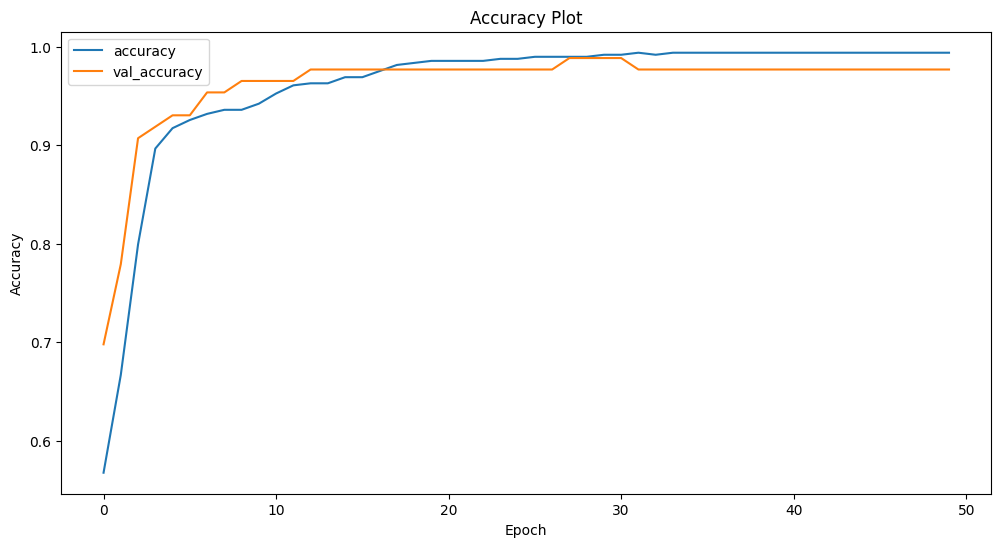

In [65]:
# Plot train curves

plt.figure(figsize=(12,6))
plt.plot(model.history.history['accuracy'], label='accuracy')
plt.plot(model.history.history['val_accuracy'], label = 'val_accuracy')
plt.title('Accuracy Plot')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



